In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

In [53]:
df=pd.read_csv(r"C:\Users\ADMIN\Documents\Data Analytics_Projects\Projects\Cookie Cats\RAW Data\cookie_cats.csv")

In [54]:
df.head()

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   userid          90189 non-null  int64 
 1   version         90189 non-null  object
 2   sum_gamerounds  90189 non-null  int64 
 3   retention_1     90189 non-null  bool  
 4   retention_7     90189 non-null  bool  
dtypes: bool(2), int64(2), object(1)
memory usage: 2.2+ MB


In [61]:
df.isnull().sum()

userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64

In [63]:
df['userid'].duplicated().sum()

np.int64(0)

In [66]:
df['version'].value_counts()

version
gate_40    45489
gate_30    44700
Name: count, dtype: int64

Exploratory Analysis

In [57]:
df.groupby('version')[['retention_1','retention_7']].mean()

,retention_1,retention_7
version,,
gate_30,0.448188,0.190201
gate_40,0.442283,0.182000


In [58]:
df['sum_gamerounds'].describe()

count    90189.000000
mean        51.872457
std        195.050858
min          0.000000
25%          5.000000
50%         16.000000
75%         51.000000
max      49854.000000
Name: sum_gamerounds, dtype: float64

In [59]:
df[df['sum_gamerounds']>1000].shape

(116, 5)

In [41]:
df.sort_values('sum_gamerounds',ascending=False).head(5)

,userid,version,sum_gamerounds,retention_1,retention_7
57702,6390605,gate_30,49854,False,True
7912,871500,gate_30,2961,True,True
29417,3271615,gate_40,2640,True,False
43671,4832608,gate_30,2438,True,True
48188,5346171,gate_40,2294,True,True


"One user (id 6390605) recorded 49,854 game rounds, 16x higher than the next-highest player — likely a bot or internal test account. Removed as a data quality issue; all other high-engagement users retained as legitimate players."

In [89]:
df_clean = df[df['userid']!=6390605].copy()

In [86]:
df_clean.groupby('version')[['retention_1','retention_7']].mean()

,retention_1,retention_7
version,,
gate_30,0.448198,0.190183
gate_40,0.442283,0.182000


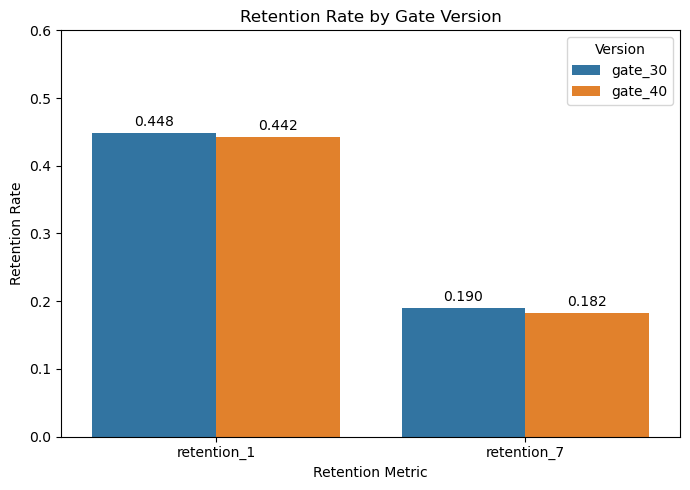

In [95]:
retention_summary = df_clean.groupby('version')[['retention_1','retention_7']].mean().reset_index()
retention_melted = retention_summary.melt(id_vars='version', var_name='metric', value_name='rate')

plt.figure(figsize=(7,5))
ax= sns.barplot(data=retention_melted, x='metric', y='rate', hue='version')
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.3f',
        padding=3)
plt.title('Retention Rate by Gate Version')
plt.xlabel('Retention Metric')
plt.ylabel('Retention Rate')
plt.ylim(0, 0.6)
plt.legend(title='Version')
plt.tight_layout()
plt.show()

Hypothesis Test (Ztest)

In [96]:
for metric in ['retention_1', 'retention_7']:
    counts = df_clean.groupby('version')[metric].sum()
    nobs = df_clean.groupby('version')[metric].count()
    stat, pval = proportions_ztest(counts, nobs)
    print(f"{metric} -> z-stat: {stat:.3f}, p-value: {pval:.4f}")

retention_1 -> z-stat: 1.787, p-value: 0.0739
retention_7 -> z-stat: 3.157, p-value: 0.0016


Confidence Interval 

In [97]:
count = df_clean.groupby('version')['retention_7'].sum()
nobs = df_clean.groupby('version')['retention_7'].count()

ci_low, ci_upp = confint_proportions_2indep(
    count1=count['gate_30'], nobs1=nobs['gate_30'],
    count2=count['gate_40'], nobs2=nobs['gate_40']
)
print('95% CI for difference (gate_30 - gate_40):', ci_low, ci_upp)

95% CI for difference (gate_30 - gate_40): 0.0031032528230339022 0.013263759453182292


Power analysis

In [98]:
baseline_rate = df_clean[df_clean['version']=='gate_40']['retention_7'].mean()
effect_size = proportion_effectsize(baseline_rate + 0.01, baseline_rate)

analysis = NormalIndPower()
n_per_group = df_clean.groupby('version').size().min()

power = analysis.power(effect_size=effect_size, nobs1=n_per_group, alpha=0.05, ratio=1)
print('Baseline rate:', round(baseline_rate, 4))
print('Power to detect 1pp lift:', round(power, 4))

Baseline rate: 0.182
Power to detect 1pp lift: 0.9696


In [102]:
for metric in ['retention_1', 'retention_7']:
    counts = df_clean.groupby('version')[metric].sum()
    nobs = df_clean.groupby('version')[metric].count()

    print("\n", metric)
    print("Counts:")
    print(counts)
    print("Nobs:")
    print(nobs)
    print("Rates:")
    print(counts / nobs)

    stat, pval = proportions_ztest(counts, nobs)
    print("Z:", stat)
    print("P:", pval)


 retention_1
Counts:
version
gate_30    20034
gate_40    20119
Name: retention_1, dtype: int64
Nobs:
version
gate_30    44699
gate_40    45489
Name: retention_1, dtype: int64
Rates:
version
gate_30    0.448198
gate_40    0.442283
Name: retention_1, dtype: float64
Z: 1.787103509763628
P: 0.0739207603418346

 retention_7
Counts:
version
gate_30    8501
gate_40    8279
Name: retention_7, dtype: int64
Nobs:
version
gate_30    44699
gate_40    45489
Name: retention_7, dtype: int64
Rates:
version
gate_30    0.190183
gate_40    0.182000
Name: retention_7, dtype: float64
Z: 3.1574100858819936
P: 0.0015917731773993442


In [103]:
count = df_clean.groupby('version')['retention_7'].sum()
nobs = df_clean.groupby('version')['retention_7'].count()

print(count)
print(nobs)

ci_low, ci_upp = confint_proportions_2indep(
    count1=count['gate_30'], nobs1=nobs['gate_30'],
    count2=count['gate_40'], nobs2=nobs['gate_40']
)

print(ci_low, ci_upp)

version
gate_30    8501
gate_40    8279
Name: retention_7, dtype: int64
version
gate_30    44699
gate_40    45489
Name: retention_7, dtype: int64
0.0031032528230339022 0.013263759453182292
